# Las heurísticas de Pan-Tompkins: qué aporta cada una

La cadena de cuatro transformaciones prepara la señal, pero no decide. La decisión —qué
joroba es un latido— vive en cuatro heurísticas que suelen omitirse cuando alguien dice
"implementé Pan-Tompkins".

Este notebook las implementa todas y mide qué pasa al apagar cada una por separado.

**Requisitos:** `numpy`, `scipy`, `matplotlib`.

In [1]:
import numpy as np
from scipy import signal as sg
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False})
FS = 500
TINTA, ROJO, VERDE, AZUL, NARANJA = '#333', '#c0392b', '#0b6e5f', '#2c5f8a', '#b8730a'

## 1. Las cuatro heurísticas

**Período refractario.** Tras despolarizarse, el ventrículo no puede volver a contraerse
durante unos 200 ms. Es una restricción biológica dura, y se programa como un bloqueo:
cualquier candidato dentro de esos 200 ms se descarta sin evaluarlo.

**Doble umbral adaptativo.** El algoritmo mantiene dos promedios móviles: SPKI, el nivel
típico de un latido, y NPKI, el del ruido. El umbral se sitúa entre ambos y se actualiza
con cada candidato. Así aprende qué es señal y qué es fondo, sin valores fijos.

**Regla de los 360 ms.** El período refractario no basta contra la onda T, que aparece
unos 280 ms después del pico R — fuera del bloqueo. La regla adicional dice: si un
candidato cae entre 200 y 360 ms del latido anterior, compara su pendiente máxima con la
de ese latido; si es menor a la mitad, es una onda T.

**Search-back.** Si pasa demasiado tiempo sin detectar nada (más de 1.66 veces el RR
medio), el algoritmo vuelve sobre el hueco con el umbral a la mitad y rescata el mayor
candidato que encuentre.

## 2. Implementación con las heurísticas conmutables

In [2]:
import numpy as np
from scipy import signal as sg

def paso_banda(x, fs, lo=5.0, hi=15.0, orden=3):
    """Etapa 1: aislar la banda donde domina el QRS."""
    sos = sg.butter(orden,[lo,hi],'bandpass',fs=fs,output='sos')
    return sg.sosfiltfilt(sos,x)

def derivada(x, fs):
    """Etapa 2: filtro diferenciador de 5 puntos del Pan-Tompkins original.

    y[n] = (1/8T)(-x[n-2] - 2x[n-1] + 2x[n+1] + x[n+2])
    Resalta pendientes abruptas; aplana ondas P y T, que son lentas.
    """
    h = np.array([-1,-2,0,2,1], dtype=float)*(fs/8.0)
    return np.convolve(x, h[::-1], mode='same')

def cuadrado(x):
    """Etapa 3: no linealidad. Todo positivo y los picos grandes se amplifican."""
    return x**2

def integrar(x, fs, ventana=0.150):
    """Etapa 4: media movil. Convierte cada QRS en una sola joroba."""
    n = max(1,int(round(ventana*fs)))
    return np.convolve(x, np.ones(n)/n, mode='same')

def cadena(x, fs, ventana=0.150, banda=(5.0,15.0)):
    b = paso_banda(x,fs,*banda)
    d = derivada(b,fs)
    c = cuadrado(d)
    i = integrar(c,fs,ventana)
    return b,d,c,i

In [3]:
import numpy as np
from scipy import signal as sg


def detectar(x, fs, umbral_adaptativo=True, refractario=True, regla_360=True,
             search_back=True, ventana=0.150, k_inicial=0.25):
    """Pan-Tompkins con sus heuristicas conmutables, para ablacion.

    Devuelve las posiciones (en segundos) de los picos R detectados.
    """
    b,d,c,integrada = cadena(x, fs, ventana=ventana)
    n = len(integrada)

    # candidatos: maximos locales de la senal integrada.
    # OJO: el parametro distance de find_peaks YA es un periodo refractario
    # implicito. Para que la ablacion sea honesta, se desactiva junto con el.
    dist = int(0.10*fs) if refractario else 1
    cand,_ = sg.find_peaks(integrada, distance=dist)
    if len(cand)==0: return np.array([]), {}

    # inicializacion sobre los primeros 2 s (fase de aprendizaje del original)
    ini = integrada[:int(2*fs)]
    SPKI = 0.25*ini.max() if len(ini) else integrada.max()*0.25
    NPKI = 0.5*ini.mean() if len(ini) else 0.0
    UMBRAL = NPKI + 0.25*(SPKI-NPKI)
    if not umbral_adaptativo:
        UMBRAL = k_inicial*np.percentile(integrada,99)

    picos=[]; rr=[]; rr_medio=None; ultimo=-np.inf
    # La "pendiente maxima" del original se mide sobre la senal DERIVADA,
    # no sobre la integrada: en el pico de la integrada la pendiente es cero.
    absd = np.abs(d)
    w_p = int(0.05*fs)
    def pend_max(q):
        a,b_ = max(0,q-w_p), min(n,q+w_p)
        return absd[a:b_].max()
    aceptados_idx=[]

    i=0
    while i < len(cand):
        p = cand[i]; tp = p/fs
        if integrada[p] > UMBRAL:
            # --- periodo refractario ---
            if refractario and (tp-ultimo) < 0.200:
                i+=1; continue
            # --- regla de los 360 ms: descartar onda T ---
            if regla_360 and picos and 0.200 <= (tp-ultimo) < 0.360:
                if pend_max(p) < 0.5*pend_max(int(ultimo*fs)):
                    if umbral_adaptativo:            # se trata como ruido
                        NPKI = 0.125*integrada[p] + 0.875*NPKI
                        UMBRAL = NPKI + 0.25*(SPKI-NPKI)
                    i+=1; continue
            picos.append(tp); aceptados_idx.append(p)
            if ultimo>-np.inf: rr.append(tp-ultimo)
            ultimo=tp
            if umbral_adaptativo:
                SPKI = 0.125*integrada[p] + 0.875*SPKI
                UMBRAL = NPKI + 0.25*(SPKI-NPKI)
        else:
            if umbral_adaptativo:
                NPKI = 0.125*integrada[p] + 0.875*NPKI
                UMBRAL = NPKI + 0.25*(SPKI-NPKI)

        # --- search-back ---
        if search_back and len(rr)>=3:
            rr_medio=np.mean(rr[-8:])
            if i+1<len(cand):
                sig_t = cand[i+1]/fs
                if (sig_t-ultimo) > 1.66*rr_medio:
                    # buscar el mayor candidato en el hueco con umbral a la mitad
                    hueco=[q for q in cand if ultimo+0.200 < q/fs < sig_t]
                    if hueco:
                        mejor=max(hueco,key=lambda q: integrada[q])
                        if integrada[mejor] > 0.5*UMBRAL:
                            tm=mejor/fs
                            picos.append(tm); aceptados_idx.append(mejor)
                            rr.append(tm-ultimo); ultimo=tm
                            if umbral_adaptativo:
                                SPKI=0.25*integrada[mejor]+0.75*SPKI
                                UMBRAL=NPKI+0.25*(SPKI-NPKI)
        i+=1

    picos=np.array(sorted(picos))
    return picos, dict(integrada=integrada, umbral_final=UMBRAL)

def evaluar(det, verd, tol=0.15):
    """Sensibilidad y valor predictivo positivo."""
    if len(det)==0: return 0.0,0.0,0,len(verd),0
    usados=set(); VP=0
    for tv in verd:
        j=int(np.argmin(np.abs(det-tv)))
        if abs(det[j]-tv)<tol and j not in usados:
            usados.add(j); VP+=1
    FN=len(verd)-VP; FP=len(det)-VP
    Se = 100*VP/max(VP+FN,1); VPP = 100*VP/max(VP+FP,1)
    return Se,VPP,VP,FN,FP

Dos detalles de implementación que importan.

**La pendiente se mide sobre la señal derivada**, no sobre la integrada. En el pico de la
señal integrada la pendiente vale cero por definición, así que compararla ahí no
discrimina nada. El artículo original habla de la pendiente máxima del complejo.

**`find_peaks(distance=...)` ya es un período refractario.** Al buscar candidatos con una
distancia mínima entre picos, se está imponiendo la heurística aunque no se escriba. Para
que la ablación sea honesta, ese parámetro se desactiva junto con el refractario
explícito.

## 3. Los escenarios

In [4]:
import numpy as np
from scipy import signal as sg
FS=500

def ecg(dur=180.0, hr=62.0, amp_r=1.30, amp_t=0.30, sigma_t=0.045,
        modulacion=0.0, desvanecer=False, semilla=7, fs=FS):
    """ECG configurable. modulacion: variacion de amplitud del QRS (0-1).
    desvanecer: la amplitud cae linealmente a la mitad en la segunda mitad."""
    rng=np.random.default_rng(semilla)
    n=int(fs*dur); t=np.arange(n)/fs; x=np.zeros(n); tr=0.5; p=[]
    while tr<dur-0.6:
        p.append(tr)
        ka = 1 + modulacion*np.sin(2*np.pi*0.20*tr)
        if desvanecer: ka *= (1.0 - 0.55*max(0.0,(tr-dur/2))/(dur/2))
        for c,a,s in [(-0.200,0.15,0.025),(-0.035,-0.10,0.008),(0.0,1.10,0.010),
                      (0.035,-0.25,0.010),(0.280,amp_t,sigma_t)]:
            x += a*ka*np.exp(-0.5*((t-(tr+c))/s)**2)
        tr += max(0.35, rng.normal(60/hr,0.045))
    return t, x*(amp_r/1.10), np.array(p)

def ruido(t, fs=FS, emg_amp=0.03, semilla=11):
    rng=np.random.default_rng(semilla)
    dv=0.35*np.sin(2*np.pi*0.28*t)+0.18*np.sin(2*np.pi*0.09*t+1.1)
    rd=0.12*np.sin(2*np.pi*60*t)+0.034*np.sin(2*np.pi*120*t+0.7)
    sos=sg.butter(4,[20,150],'bandpass',fs=fs,output='sos')
    return dv+rd+emg_amp*sg.sosfilt(sos,rng.standard_normal(len(t)))

ESCENARIOS = {
 'normal':            dict(),
 'T picuda':          dict(amp_t=0.70, sigma_t=0.028),
 'amplitud variable': dict(modulacion=0.55),
 'señal que decae':   dict(desvanecer=True),
 'taquicardia':       dict(hr=145),
}

Cinco situaciones, cada una pensada para estresar una heurística distinta: un registro
normal, uno con onda T picuda (hiperkalemia), uno con amplitud del QRS modulada por la
respiración, uno donde la señal se degrada a la mitad del registro, y taquicardia a
145 lpm.

## 4. La ablación

In [5]:
CONFIGS = [
 ('completo',                dict()),
 ('sin umbral adaptativo',   dict(umbral_adaptativo=False)),
 ('sin período refractario', dict(refractario=False)),
 ('sin regla de 360 ms',     dict(regla_360=False)),
 ('sin search-back',         dict(search_back=False)),
]

for nombre_esc, kw in ESCENARIOS.items():
    t, limpio, pv = ecg(**kw)
    x = limpio + ruido(t)
    print(f'\n=== {nombre_esc}  ({len(pv)} latidos) ===')
    print(f'{"configuración":>26} | {"Se":>7} | {"VPP":>7} | {"VP":>4} {"FN":>4} {"FP":>5}')
    print('-'*67)
    for nombre, cfg in CONFIGS:
        d, _ = detectar(x, FS, **cfg)
        Se, VPP, VP, FN, FP = evaluar(d, pv)
        print(f'{nombre:>26} | {Se:>6.1f}% | {VPP:>6.1f}% | {VP:>4} {FN:>4} {FP:>5}')


=== normal  (187 latidos) ===
             configuración |      Se |     VPP |   VP   FN    FP
-------------------------------------------------------------------
                  completo |  100.0% |  100.0% |  187    0     0
     sin umbral adaptativo |  100.0% |  100.0% |  187    0     0


   sin período refractario |  100.0% |   27.1% |  187    0   502
       sin regla de 360 ms |  100.0% |  100.0% |  187    0     0
           sin search-back |  100.0% |  100.0% |  187    0     0



=== T picuda  (187 latidos) ===
             configuración |      Se |     VPP |   VP   FN    FP
-------------------------------------------------------------------
                  completo |  100.0% |  100.0% |  187    0     0
     sin umbral adaptativo |  100.0% |  100.0% |  187    0     0


   sin período refractario |  100.0% |   22.7% |  187    0   635
       sin regla de 360 ms |  100.0% |   50.0% |  187    0   187
           sin search-back |  100.0% |  100.0% |  187    0     0



=== amplitud variable  (187 latidos) ===
             configuración |      Se |     VPP |   VP   FN    FP
-------------------------------------------------------------------
                  completo |   99.5% |  100.0% |  186    1     0
     sin umbral adaptativo |   82.9% |  100.0% |  155   32     0


   sin período refractario |  100.0% |   30.5% |  187    0   427
       sin regla de 360 ms |   99.5% |  100.0% |  186    1     0
           sin search-back |   71.7% |  100.0% |  134   53     0



=== señal que decae  (187 latidos) ===
             configuración |      Se |     VPP |   VP   FN    FP
-------------------------------------------------------------------
                  completo |  100.0% |  100.0% |  187    0     0
     sin umbral adaptativo |  100.0% |  100.0% |  187    0     0


   sin período refractario |  100.0% |   27.1% |  187    0   503
       sin regla de 360 ms |  100.0% |  100.0% |  187    0     0
           sin search-back |  100.0% |  100.0% |  187    0     0



=== taquicardia  (436 latidos) ===
             configuración |      Se |     VPP |   VP   FN    FP
-------------------------------------------------------------------
                  completo |  100.0% |  100.0% |  436    0     0
     sin umbral adaptativo |  100.0% |  100.0% |  436    0     0


   sin período refractario |  100.0% |   27.8% |  436    0  1134
       sin regla de 360 ms |  100.0% |  100.0% |  436    0     0
           sin search-back |  100.0% |  100.0% |  436    0     0


## 5. Lectura de los resultados

**El período refractario es, con diferencia, la heurística más importante.** Sin él, el
valor predictivo positivo se derrumba al 23–30% en todos los escenarios, incluido el
normal: cada QRS genera varios candidatos y todos se cuentan como latidos.

**Las otras tres son invisibles en señal normal.** En el escenario limpio, quitar el
umbral adaptativo, la regla de 360 ms o el search-back no cambia nada. Cada una existe
para un modo de fallo concreto:

- la regla de 360 ms solo actúa con onda T picuda, donde salva el VPP del 50% al 100%
- el umbral adaptativo y el search-back solo actúan con amplitud variable, donde levantan
  la sensibilidad del 83% y el 72% al 99.5%

Esa es la razón de que tantas implementaciones incompletas parezcan correctas: **en un
registro limpio, un detector sin heurísticas funciona igual de bien**. La diferencia
aparece exactamente donde importa, que es en el registro difícil.

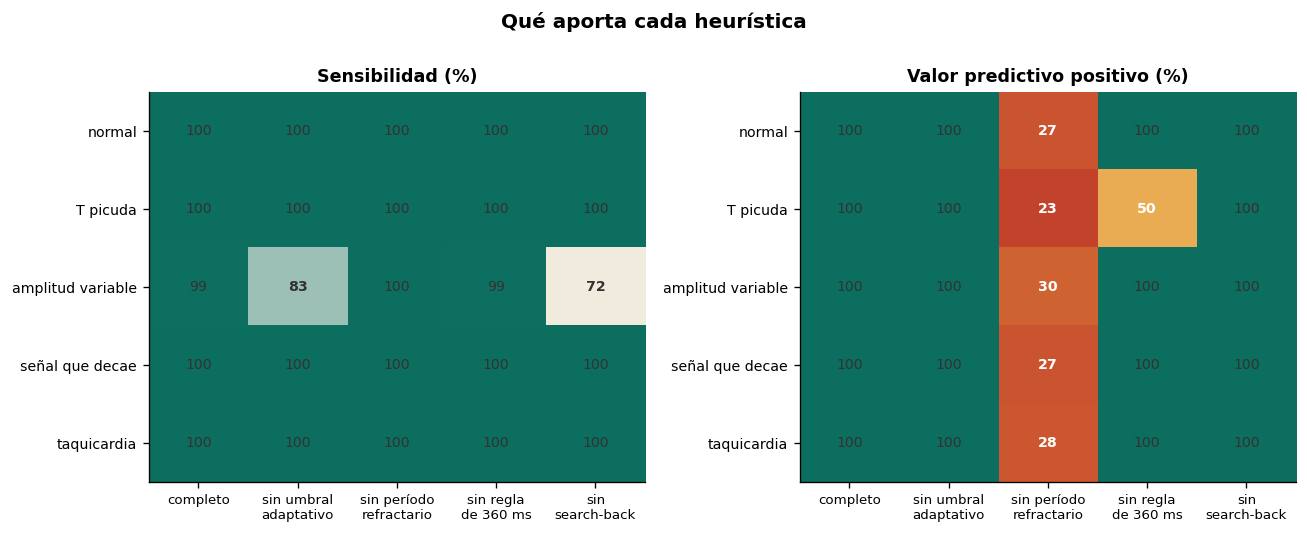

In [6]:
CONF = [('completo', {}), ('sin umbral\nadaptativo', dict(umbral_adaptativo=False)),
        ('sin período\nrefractario', dict(refractario=False)),
        ('sin regla\nde 360 ms', dict(regla_360=False)),
        ('sin\nsearch-back', dict(search_back=False))]

Se = np.zeros((len(ESCENARIOS), len(CONF))); VP = np.zeros_like(Se)
for r, (ne, kw) in enumerate(ESCENARIOS.items()):
    t, li, pv = ecg(**kw); x = li + ruido(t)
    for c, (nc, cfg) in enumerate(CONF):
        d, _ = detectar(x, FS, **cfg); s, v, _, _, _ = evaluar(d, pv)
        Se[r, c] = s; VP[r, c] = v

cmap = LinearSegmentedColormap.from_list('x', [ROJO, '#e8a33d', '#f2f0e9', VERDE])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, M, tit in zip(axes, [Se, VP], ['Sensibilidad (%)', 'Valor predictivo positivo (%)']):
    ax.imshow(M, cmap=cmap, vmin=20, vmax=100, aspect='auto')
    ax.set_xticks(range(len(CONF))); ax.set_xticklabels([c[0] for c in CONF], fontsize=8)
    ax.set_yticks(range(len(ESCENARIOS))); ax.set_yticklabels(list(ESCENARIOS), fontsize=8.5)
    ax.set_title(tit, fontweight='bold', fontsize=10.5); ax.grid(False)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f'{M[i,j]:.0f}', ha='center', va='center', fontsize=8.5,
                    color='white' if M[i,j] < 55 else TINTA,
                    fontweight='bold' if M[i,j] < 95 else 'normal')
fig.suptitle('Qué aporta cada heurística', fontweight='bold', y=1.0)
fig.tight_layout()
plt.show()

## 6. Hasta dónde protege la regla de los 360 ms

La regla descarta un candidato si su pendiente es menor a la mitad de la del latido
anterior. Ese umbral del 50% es un parámetro, y conviene saber dónde deja de servir.

Barremos la "picudez" de la onda T y medimos la razón real entre pendientes.

In [7]:
from pantom import cadena as _cadena

filas = []
for sT, aT in [(0.045,0.30), (0.038,0.45), (0.035,0.50), (0.032,0.55), (0.030,0.60),
               (0.028,0.70), (0.026,0.70), (0.025,0.70), (0.024,0.72), (0.022,0.75),
               (0.020,0.80), (0.017,0.85), (0.015,0.90)]:
    t, li, pv = ecg(amp_t=aT, sigma_t=sT); x = li + ruido(t)
    b, d, c, i = _cadena(x, FS)
    absd = np.abs(d); w = int(0.05*FS)
    pm = lambda q: absd[max(0,q-w):min(len(absd),q+w)].max()
    razon = np.mean([pm(int((tr+0.280)*FS))/max(pm(int(tr*FS)), 1e-9) for tr in pv[2:-2]])
    dc, _ = detectar(x, FS);                  _, vc, _, _, _ = evaluar(dc, pv)
    ds, _ = detectar(x, FS, regla_360=False); _, vs, _, _, _ = evaluar(ds, pv)
    filas.append((razon, vc, vs))

filas = np.array(sorted(filas))
print(f'{"pend. T / pend. QRS":>21} | {"con regla":>10} | {"sin regla":>10}')
print('-'*47)
for r, vc, vs in filas:
    print(f'{r:>21.2f} | {vc:>9.1f}% | {vs:>9.1f}%')

  pend. T / pend. QRS |  con regla |  sin regla
-----------------------------------------------
                 0.06 |     100.0% |     100.0%
                 0.14 |     100.0% |     100.0%
                 0.18 |     100.0% |     100.0%
                 0.24 |     100.0% |     100.0%
                 0.29 |     100.0% |     100.0%
                 0.37 |     100.0% |      50.0%
                 0.41 |     100.0% |      50.0%
                 0.43 |     100.0% |      50.0%
                 0.46 |     100.0% |      50.0%
                 0.52 |      50.0% |      50.0%
                 0.59 |      50.0% |      50.0%
                 0.68 |      50.0% |      50.0%
                 0.73 |      50.0% |      50.0%


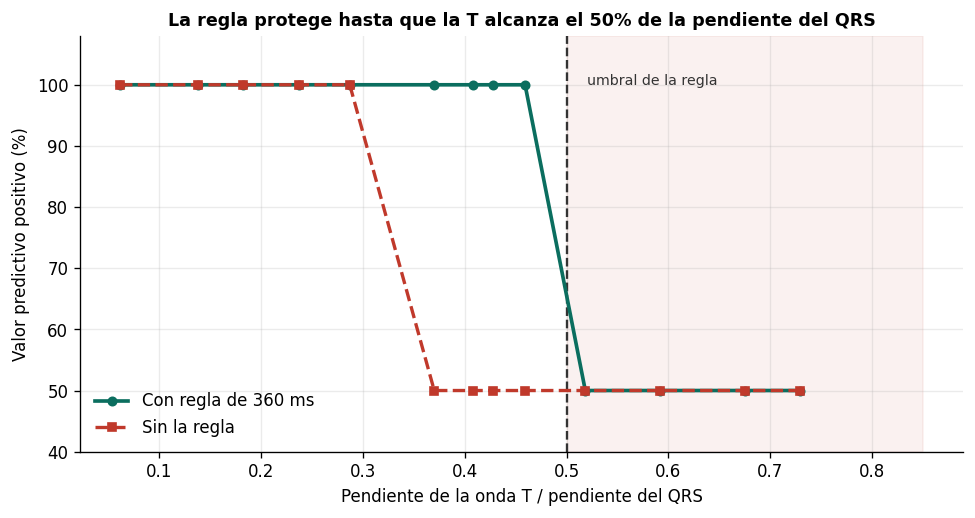

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.axvline(0.5, color=TINTA, ls='--', lw=1.4)
ax.axvspan(0.5, 0.85, color=ROJO, alpha=0.07)
ax.plot(filas[:,0], filas[:,1], color=VERDE, lw=2.2, marker='o', ms=5,
        label='Con regla de 360 ms')
ax.plot(filas[:,0], filas[:,2], color=ROJO, lw=2.0, marker='s', ms=5, ls='--',
        label='Sin la regla')
ax.set_xlabel('Pendiente de la onda T / pendiente del QRS')
ax.set_ylabel('Valor predictivo positivo (%)')
ax.set_title('La regla protege hasta que la T alcanza el 50% de la pendiente del QRS',
             fontweight='bold', fontsize=10.5)
ax.legend(loc='lower left', frameon=False); ax.set_ylim(40, 108)
ax.text(0.52, 100, 'umbral de la regla', fontsize=8.5, color=TINTA)
plt.show()

La curva verde cae exactamente en 0.5 — el umbral que define la regla. No es coincidencia:
la regla funciona mientras la pendiente de la T se mantenga por debajo del 50%, y falla en
cuanto lo supera.

Fuera de esa zona, ambas curvas se juntan en 50% de VPP: un falso positivo por cada
latido, es decir, la frecuencia cardiaca reportada se duplica.

**El umbral del 50% no es sagrado.** Es un parámetro que se puede endurecer si se espera
onda T prominente, a costa de descartar extrasístoles reales que sí aparecen poco después
del latido previo. Ese es el compromiso.

## 7. El search-back en acción

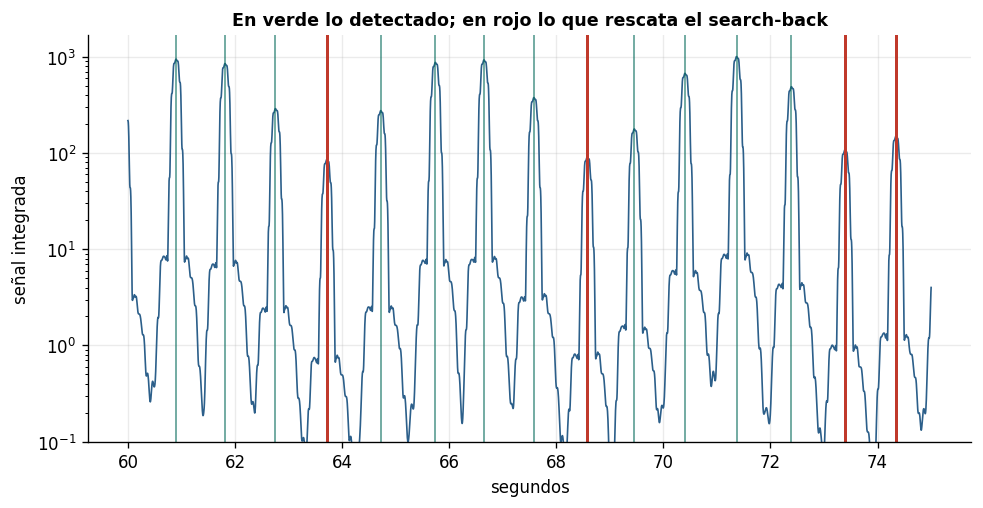

4 latidos rescatados en esta ventana de 15 s


In [9]:
t, li, pv = ecg(modulacion=0.55); x = li + ruido(t)
b, d, c, integ = _cadena(x, FS)
d_ok, _ = detectar(x, FS)
d_sb, _ = detectar(x, FS, search_back=False)

V = (t >= 60) & (t <= 75)
rescatados = [p for p in d_ok if V[int(p*FS)] and np.min(np.abs(d_sb - p)) > 0.05]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(t[V], integ[V], color=AZUL, lw=1.0)
for p in d_ok[(d_ok > 60) & (d_ok < 75)]:
    ax.axvline(p, color=VERDE, lw=0.9, alpha=0.75)
for p in rescatados:
    ax.axvline(p, color=ROJO, lw=1.8)
ax.set_yscale('log'); ax.set_xlabel('segundos'); ax.set_ylabel('señal integrada')
ax.set_title('En verde lo detectado; en rojo lo que rescata el search-back',
             fontweight='bold', fontsize=10.5)
ax.set_ylim(1e-1, None)
plt.show()
print(f'{len(rescatados)} latidos rescatados en esta ventana de 15 s')

Cuando la amplitud del QRS cae, el umbral adaptativo tarda en bajar y algunos latidos
quedan por debajo. El search-back los recupera revisando el hueco con el umbral a la
mitad.

Es una heurística deliberadamente asimétrica: prefiere arriesgar un falso positivo antes
que perder un latido. En un monitor cardiaco esa asimetría es la correcta — no detectar
una asistolia es peor que dar una alarma de más.

## Dónde falla esto

**La señal es sintética.** Los escenarios están construidos para estresar una heurística
cada uno. Un registro real presenta varios problemas a la vez, y las heurísticas
interactúan de formas que esta ablación no captura.

**No hay arritmias.** Extrasístoles ventriculares, fibrilación auricular y pausas
sinusales cambian el juego: el search-back puede inventar latidos en una pausa real, y la
regla de 360 ms puede descartar una extrasístole legítima. Evaluar eso requiere registros
anotados por cardiólogo.

**Los parámetros son los del artículo original** (0.125 de tasa de aprendizaje, 0.25 de
factor de umbral, 1.66 para el search-back). Están ajustados sobre MIT-BIH y no
necesariamente son óptimos en otra población o instrumentación.

**La evaluación honesta contra una base anotada** —sensibilidad y VPP sobre registros
reales, comparados con detectores alternativos— es el tema siguiente.

## Referencias

- Pan J., Tompkins W. *A Real-Time QRS Detection Algorithm.* IEEE Trans. Biomed. Eng., 1985.
- Hamilton P., Tompkins W. *Quantitative investigation of QRS detection rules using the
  MIT/BIH arrhythmia database.* IEEE Trans. Biomed. Eng., 1986.